In [1]:
import wandb
import pandas as pd
import os
import json

import seaborn as sns
import matplotlib.pyplot as plt
from plots.utils import load_runs_from_wandb

In [ ]:
run_names = [
    # LinearGater Runs:
    "18M_2025.08.31_09.35",
    "32M_2025.08.31_12.06",
    # "73M_2025.08.24_09.01",
    "73M_2025.08.31_05.11",
    "130M_2025.08.24_09.01",
    # RandomGater Runs:
    "j2tkor55",
    "xjdm3gvb",
    "73M_2025.08.30_08.19",
    "130M_2025.08.30_08.19",
    # Nawrot Runs:
    "18M_2025.09.03_05.39",
    "32M_2025.09.03_05.39",
    "73M_2025.09.04_08.54",
    "130M_2025.09.03_05.34",
    # SequentialDependentLinearGater Runs:
    "18M_2025.09.17_07.52",
    "32M_2025.09.17_07.52",
    "73M_2025.09.17_07.52",
    "130M_2025.09.20_07.07",
    # ScaledSequentialyDependentLinearGater Runs:
    "18M_2025.09.29_03.44",
    "32M_2025.09.28_23.19",
    "73M_2025.10.06_08.08",
    "130M_2025.10.05_02.16",
    # Flexify Runs:
    # "32M_2025.10.12_00.54",
    # "73M_2025.10.12_22.42",
    # Non-deviation runs:
    "18M_2025.10.28_19.02",
    "32M_2025.10.28_19.02",
    "73M_2025.10.27_05.53",
    "130M_2025.10.31_06.36"
]

In [3]:
df, configs = load_runs_from_wandb(run_names)

wandb: Currently logged in as: samdauncey (samdauncey-eth-z-rich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:
print("hours to train:")
df.groupby(["GaterClass", "model_size"])["batch_wallclock_time"].sum() / (60*60)

hours to train:


GaterClass                                model_size
ExactRandomGater                          130M           8.307443
                                          18M            2.170575
                                          32M            2.762485
                                          73M            7.569247
LinearGater                               130M          12.899694
                                          18M            2.382674
                                          32M            2.818287
                                          73M            8.371114
NawrotGater                               130M          11.099253
                                          18M            2.588639
                                          32M            3.059011
                                          73M            8.065567
OptimizedSequentialyDependentLinearGater  130M          20.020264
                                          18M            6.677775
                       

In [51]:
for config in configs:
    if 'consistency_loss_weight' in config:
        consistency_loss_weight = config['consistency_loss_weight']
    else:
        consistency_loss_weight=2.
    
    if 'relative_gating_loss_weight' in config:
        relative_gating_loss_weight = config['relative_gating_loss_weight']
    else:
        relative_gating_loss_weight = 1.
    
    print(f"{config['model_size']} {config['GaterClass']} {consistency_loss_weight=} {relative_gating_loss_weight=}")

18M LinearGater consistency_loss_weight=2.0 relative_gating_loss_weight=1.0
32M LinearGater consistency_loss_weight=2.0 relative_gating_loss_weight=1.0
73M LinearGater consistency_loss_weight=2.0 relative_gating_loss_weight=1.0
130M LinearGater consistency_loss_weight=2.0 relative_gating_loss_weight=1.0
18M ExactRandomGater consistency_loss_weight=2.0 relative_gating_loss_weight=1.0
32M ExactRandomGater consistency_loss_weight=2.0 relative_gating_loss_weight=1.0
73M ExactRandomGater consistency_loss_weight=2.0 relative_gating_loss_weight=1.0
130M ExactRandomGater consistency_loss_weight=2.0 relative_gating_loss_weight=1.0
18M NawrotGater consistency_loss_weight=2.0 relative_gating_loss_weight=0
32M NawrotGater consistency_loss_weight=2.0 relative_gating_loss_weight=0
73M NawrotGater consistency_loss_weight=2.0 relative_gating_loss_weight=0
130M NawrotGater consistency_loss_weight=2.0 relative_gating_loss_weight=0
18M OptimizedSequentialyDependentLinearGater consistency_loss_weight=2.0 

In [20]:
config

{'seed': 42,
 'num_heads': 12,
 'GaterClass': 'ScaledSequentialyDependentLinearGater',
 'batch_size': 8,
 'flash_attn': True,
 'model_size': '73M',
 'num_epochs': 1,
 'vocab_size': 320,
 'bytes_limit': 3400000000,
 'n_up_layers': 2,
 'gater_kwargs': {'filter_size': 8, 'scale_factor': 0.0625},
 'learn_gating': True,
 'n_mid_layers': 6,
 'warmup_bytes': 250000000,
 'discount_rate': 0.99,
 'embedding_dim': 768,
 'learning_rate': 0.0024,
 'n_down_layers': 2,
 'max_seq_length': 4096,
 'sliding_window': 64,
 'stop_condition': 'BytesLimitCondition',
 'training_bytes': 3400000000,
 'validate_every': 100,
 'downsample_rate': 0.25,
 'DownSamplerClass': 'SelectTokenDownsampler',
 'lr_total_updates': 103759.765625,
 'step_print_every': 1,
 'warm_start_steps': None,
 'lr_warmup_updates': 7629.39453125,
 'effective_batch_size': 32,
 'consistency_loss_weight': 0.1,
 'downsample_rate_schedule': '<clean_code.downsample_rate_scheduler.RandomChoiceDownsampleRateScheduler object at 0x7f53127146d0>',
 'ear

In [52]:
val_steps = df["val_true_downsample_rate"].notna()
df_val = df[
    val_steps
]

df_val.head()

,flops,batch_wallclock_time,_step,ar_loss,late_ar_loss,val_ar_loss,val_total_loss,pre_clip_grad_norm,all_bytes_elapsed,val_early_ar_loss,...,_timestamp,val_mean_selected_action_ce,val_late_ar_loss,early_ar_loss,flops_elapsed,val_true_downsample_rate,non_padding_bytes,run_name,model_size,GaterClass
0,2.374978e+12,0.749340,0,8.573084,9.055325,8.521752,8.642275,13.312500,32768.0,6.645210,...,1.756626e+09,0.625732,8.990888,6.644122,2.374978e+12,0.523071,32768,18M_2025.08.31_09.35,18M,LinearGater
400,1.651543e+12,0.516900,400,2.709438,2.772559,2.748716,2.740452,3.421875,13139968.0,2.509507,...,1.756626e+09,0.115997,2.808519,2.456954,6.305649e+14,0.270813,32768,18M_2025.08.31_09.35,18M,LinearGater
800,1.635905e+12,0.255147,800,2.268645,2.259535,2.244359,2.241819,0.429688,26247168.0,2.280220,...,1.756626e+09,0.033417,2.235394,2.305081,1.292540e+15,0.263428,32768,18M_2025.08.31_09.35,18M,LinearGater
1200,1.671261e+12,0.302657,1200,1.747365,1.708599,1.817326,1.816636,0.239258,39354368.0,1.949189,...,1.756626e+09,0.010626,1.784360,1.902426,1.959602e+15,0.273743,32768,18M_2025.08.31_09.35,18M,LinearGater
1600,1.690979e+12,0.345283,1600,1.607265,1.560128,1.641461,1.641726,0.154297,52461568.0,1.827665,...,1.756626e+09,0.004313,1.594910,1.795812,2.627586e+15,0.272583,32768,18M_2025.08.31_09.35,18M,LinearGater


In [54]:
df_val.keys()

Index(['flops', 'batch_wallclock_time', '_step', 'ar_loss', 'late_ar_loss',
       'val_ar_loss', 'val_total_loss', 'pre_clip_grad_norm',
       'all_bytes_elapsed', 'val_early_ar_loss', 'gating_loss',
       'val_gating_loss', 'downsample_rate_target',
       'val_downsample_rate_target', 'all_bytes', 'total_loss',
       'val_in_context_learning_score', 'non_padding_bytes_elapsed',
       'learning_rate', 'val_rate_consistency_loss', '_runtime',
       'model_flops_utilization', 'rate_consistency_loss',
       'true_downsample_rate', 'mean_selected_action_ce',
       'in_context_learning_score', '_timestamp',
       'val_mean_selected_action_ce', 'val_late_ar_loss', 'early_ar_loss',
       'flops_elapsed', 'val_true_downsample_rate', 'non_padding_bytes',
       'run_name', 'model_size', 'GaterClass'],
      dtype='object')

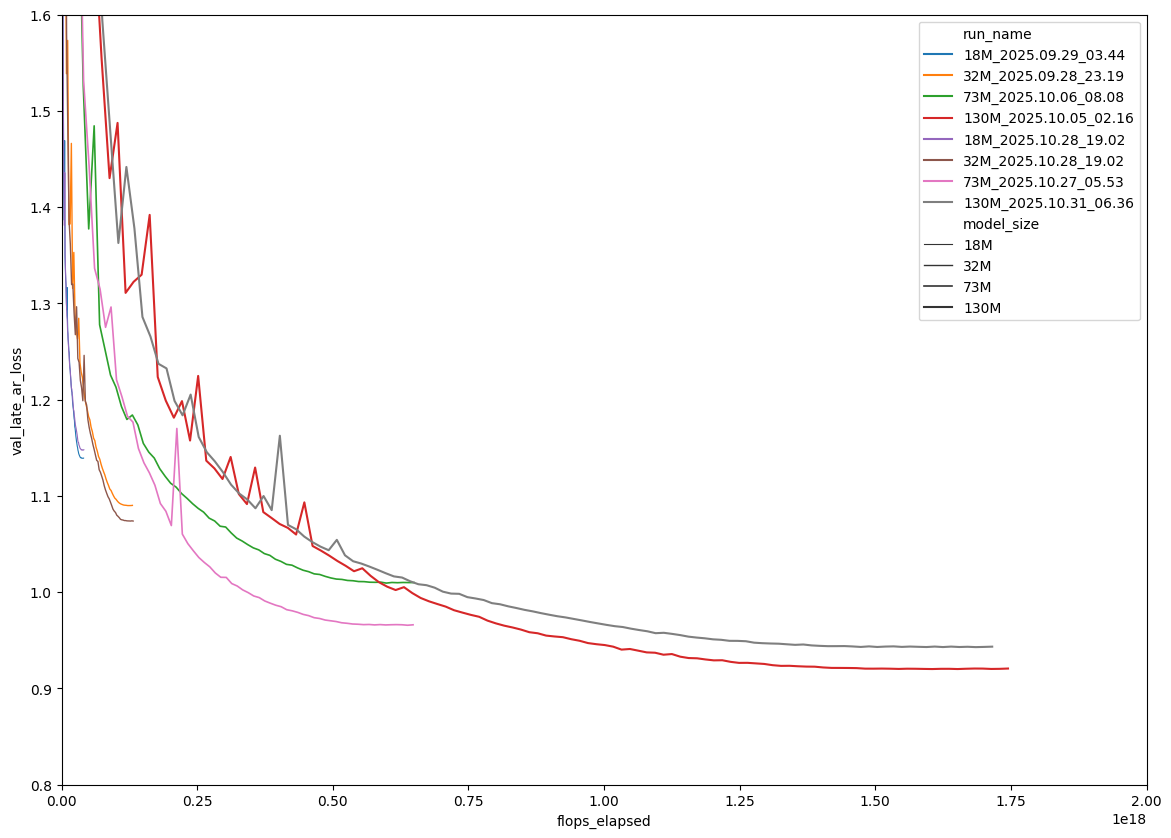

In [58]:
plt.figure(figsize=(14, 10))

df_val_of_interest = df_val[df_val["GaterClass"] == "ScaledSequentialyDependentLinearGater"]

sizes = {
    "18M": 0.8,
    "32M": 1.,
    "73M": 1.2,
    "130M": 1.5
}

sns.lineplot(
    data=df_val_of_interest,
    x="flops_elapsed",
    y="val_late_ar_loss",
    hue="run_name",
    size="model_size",
    sizes=sizes
)

plt.ylim(0.8, 1.6)
plt.xlim(0, 2e18)

plt.show()

<Axes: xlabel='all_bytes_elapsed', ylabel='mean_selected_action_ce'>

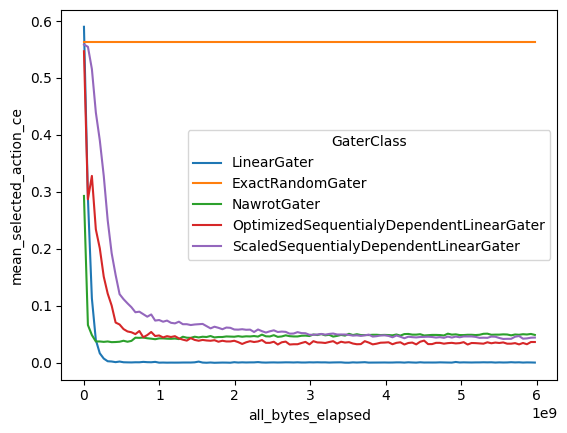

In [23]:


sns.lineplot(
    data=df_val[df_val["model_size"] == "130M"],
    x="all_bytes_elapsed",
    y="mean_selected_action_ce",
    hue="GaterClass",
)